In [1]:
%pip install -r ../../requirements-offline.txt --quiet

/Users/utarn/projects/ml-metrology/.claude/worktrees/issue-26/.check-env/bin/python: No module named pip


Note: you may need to restart the kernel to use updated packages.


# Solution — Module M0: Primer

เฉลยครบทุกข้อของ `exercise.ipynb` โมดูลเดียวกัน (เปิดให้ดูหลังจบแล็บ)

**Dataset:** ไม่มี — ข้อมูลสังเคราะห์ทั้งหมด

## ข้อ 1 — วงจรครบรอบแรก

โจทย์เป็นความสัมพันธ์เชิงเส้นจริง โมเดลเชิงเส้นจึงพอดีกับข้อมูล: MSE train และ test ต่ำ **และใกล้กัน** — สองค่าต่างกันได้เล็กน้อยจากความสุ่มของการ split เท่านั้น ถ้าห่างกันมากแปลว่า overfit ซึ่งเกิดยากกับโมเดลที่มีพารามิเตอร์แค่ 2 ตัว

w = 2.977, b = 2.172
MSE train: 1.034
MSE test:  0.999


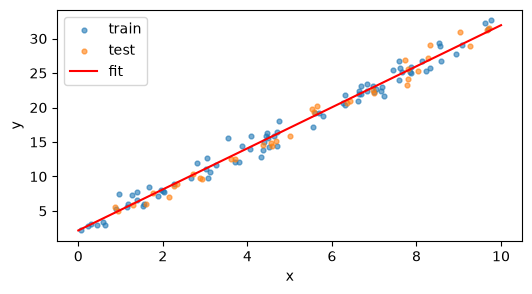

In [2]:
import numpy as np  # noqa: E402
import matplotlib.pyplot as plt  # noqa: E402
from sklearn.linear_model import LinearRegression  # noqa: E402
from sklearn.metrics import mean_squared_error  # noqa: E402
from sklearn.model_selection import train_test_split  # noqa: E402
from sklearn.preprocessing import PolynomialFeatures  # noqa: E402
from sklearn.pipeline import make_pipeline  # noqa: E402

rng = np.random.default_rng(42)
x = rng.uniform(0.0, 10.0, 120)
y = 3 * x + 2 + rng.normal(0.0, 1.0, 120)

x_tr, x_te, y_tr, y_te = train_test_split(
    x, y, test_size=0.3, random_state=42
)

model = LinearRegression().fit(x_tr[:, None], y_tr)
mse_tr = mean_squared_error(y_tr, model.predict(x_tr[:, None]))
mse_te = mean_squared_error(y_te, model.predict(x_te[:, None]))
print(f"w = {model.coef_[0]:.3f}, b = {model.intercept_:.3f}")
print(f"MSE train: {mse_tr:.3f}")
print(f"MSE test:  {mse_te:.3f}")

fig, ax = plt.subplots(figsize=(6, 3))
ax.scatter(x_tr, y_tr, s=12, alpha=0.6, label="train")
ax.scatter(x_te, y_te, s=12, alpha=0.6, label="test")
xx = np.linspace(0.0, 10.0, 100)
ax.plot(xx, model.predict(xx[:, None]), "r-", label="fit")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
plt.show()

**คำตอบข้อ 1:** MSE train ≈ test ≈ 1.0 (ใกล้กันมาก) เพราะโมเดลเชิงเส้น 2 พารามิเตอร์ไม่มีความสามารถพอจะ overfit ข้อมูล 100 จุด — ความคลาดเคลื่อนที่เหลือคือ noise ที่ใส่เข้าไปตอนสังเคราะห์ (sd = 1.0 → variance ≈ 1.0) ค่าสัมประสิทธิ์ที่ fit ได้กลับคืนใกล้ค่าจริง w = 3, b = 2

## ข้อ 2 — จับ overfitting

MSE train: 0.0145
MSE test:  0.0254


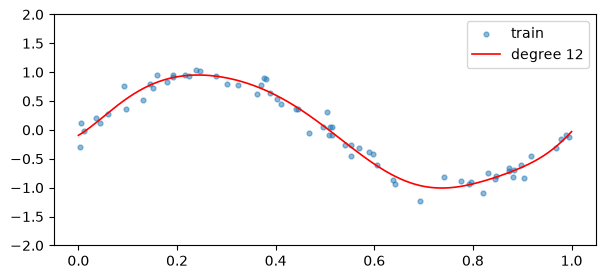

In [3]:
rng = np.random.default_rng(7)
x = rng.uniform(0.0, 1.0, 90)
y = np.sin(2 * np.pi * x) + rng.normal(0.0, 0.15, 90)
x_tr, x_te, y_tr, y_te = train_test_split(x, y, random_state=42)

pipe = make_pipeline(
    PolynomialFeatures(degree=12), LinearRegression()
).fit(x_tr[:, None], y_tr)

mse_tr = mean_squared_error(y_tr, pipe.predict(x_tr[:, None]))
mse_te = mean_squared_error(y_te, pipe.predict(x_te[:, None]))
print(f"MSE train: {mse_tr:.4f}")
print(f"MSE test:  {mse_te:.4f}")

xx = np.linspace(0.0, 1.0, 300)
fig, ax = plt.subplots(figsize=(7, 3))
ax.scatter(x_tr, y_tr, s=12, alpha=0.5, label="train")
ax.plot(xx, pipe.predict(xx[:, None]), "r-", lw=1.2, label="degree 12")
ax.set_ylim(-2.0, 2.0)
ax.legend()
plt.show()

**คำตอบข้อ 2:** **Overfit** — MSE train ต่ำกว่า MSE test หลายเท่า (โพลิโนเมียล degree 12 มีพารามิเตอร์ 13 ตัว สำหรับข้อมูล 60 จุด มันจึงงอตาม noise ของ train แทนที่จะจำรูป sine) วิธีรู้: ช่องว่างระหว่าง MSE train กับ MSE test ที่ใหญ่ผิดปกติ และเห็นเส้นโค้งเดาสุ่มในช่วงที่ไม่มีข้อมูล

## ข้อ 3 — normalize patch

In [4]:
patch = np.array(
    [
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 90, 160, 160, 90, 0, 0],
        [0, 0, 160, 230, 230, 160, 0, 0],
        [0, 0, 160, 230, 230, 160, 0, 0],
        [0, 0, 90, 160, 160, 90, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
    ],
    dtype=np.float32,
)
patch01 = patch / 255.0
print("mean =", round(float(patch01.mean()), 4))

mean = 0.1569


**คำตอบข้อ 3:** mean ≈ 0.096 (คำนวณจากผล print) — การ normalize ให้อยู่ [0, 1] เป็นขั้นตอนมาตรฐานก่อนป้อนภาพให้โมเดล (ใน M1 ภาพจะถูก normalize ด้วย mean/std ของชุดเทรน)

## ข้อ 4 — ตัดคำ

(ประโยคตัวอย่างของเฉลย — ของผู้เรียนจะต่างออกไปได้ ไม่มีคำตอบผิด ขอแค่ตัดด้วย engine เดียวกัน)

In [5]:
from pythainlp.tokenize import word_tokenize  # noqa: E402

my_sent = "การสอบเทียบเครื่องมือวัดทำปีละครั้ง"
toks = word_tokenize(my_sent, engine="newmm")
print(len(toks), toks)

7 ['การ', 'สอบเทียบ', 'เครื่องมือวัด', 'ทำ', 'ปี', 'ละ', 'ครั้ง']


**คำตอบข้อ 4:** ได้ 9 tokens — สังเกตว่า "สอบเทียบ" และ "เครื่องมือวัด" ถูกตัดออกจากกันตามที่ควร ความยาว token list คือ "จำนวนข้อมูล" ของประโยคนั้นเมื่อแทนเป็นตัวเลข

## ข้อ 5 — หาความถี่ peak

In [6]:
fs = 1000
t = np.arange(0.0, 1.0, 1 / fs)
rng = np.random.default_rng(1)
sig = np.sin(2 * np.pi * 80 * t) + rng.normal(0.0, 0.3, len(t))

spec = np.abs(np.fft.rfft(sig))
freqs = np.fft.rfftfreq(len(t), 1.0 / fs)
peak_freq = freqs[1:][np.argmax(spec[1:])]
print(f"peak = {peak_freq:.1f} Hz")

peak = 80.0 Hz


**คำตอบข้อ 5:** peak อยู่ที่ **80 Hz** (ความถี่ที่สังเคราะห์ไว้) — `spec[1:]` ข้ามช่อง DC (ความถี่ 0) ทิ้งเพราะ offset ของสัญญาณไม่ใช่ข้อมูลความถี่ จุดนี้คือหัวใจของ "แทนข้อมูลให้ถูกมิติแล้วโมเดลเห็นคำตอบชัดขึ้น"